# Exploratory Data Analysis & Feature Engineering Comparison

In this notebook, we compare the correlation patterns in the Maternal Health Risk dataset before and after applying clinical feature engineering.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Set Seaborn theme for premium aesthetics
sns.set_theme(style="whitegrid", palette="magma")

# Load the real dataset
data_path = os.path.join("..", "data", "Maternal Health Risk Data Set.csv")
df = pd.read_csv(data_path)

# Encode RiskLevel for correlation analysis
risk_map = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df_encoded = df.copy()
df_encoded['RiskLevel'] = df_encoded['RiskLevel'].map(risk_map)

print("Data loaded and target encoded.")
df.head()

Data loaded and target encoded.


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## 1. Class Distribution

Using Seaborn's `countplot` to visualize the frequency of each risk category.

## 1. Data Quality & Missing Value Audit

Before analysis, we verify the completeness of the dataset. A high-quality predictive model requires a clean foundation without significant gaps in clinical data.

C:\Users\shiro\AppData\Local\Temp\ipykernel_13816\3915404912.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_data, x='Missing Count', y='Feature', palette='crest')


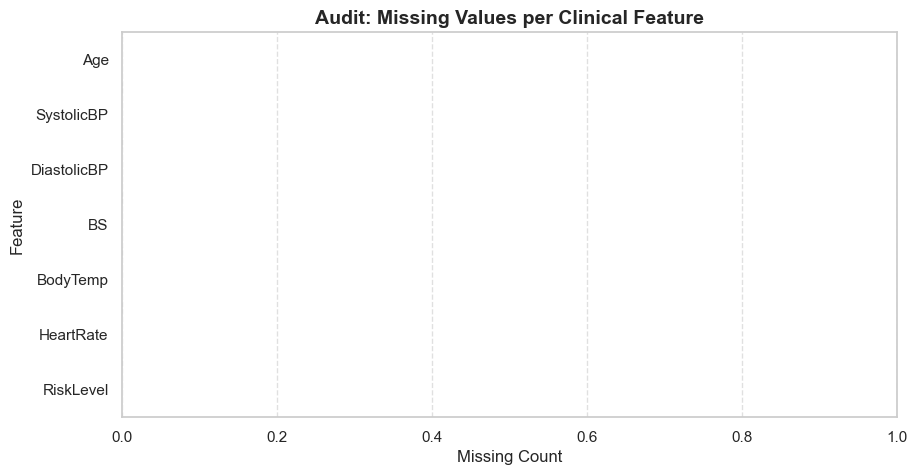

Total missing values: 0


In [2]:
# Missing Value Summary
missing_data = df.isnull().sum().reset_index()
missing_data.columns = ['Feature', 'Missing Count']

plt.figure(figsize=(10, 5))
sns.barplot(data=missing_data, x='Missing Count', y='Feature', palette='crest')
plt.title('Audit: Missing Values per Clinical Feature', fontsize=14, fontweight='bold')
plt.xlim(0, max(missing_data['Missing Count']) + 1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.savefig('../figures/missing_values_audit.png', dpi=150, bbox_inches='tight')
plt.show()

print("Total missing values:", df.isnull().sum().sum())

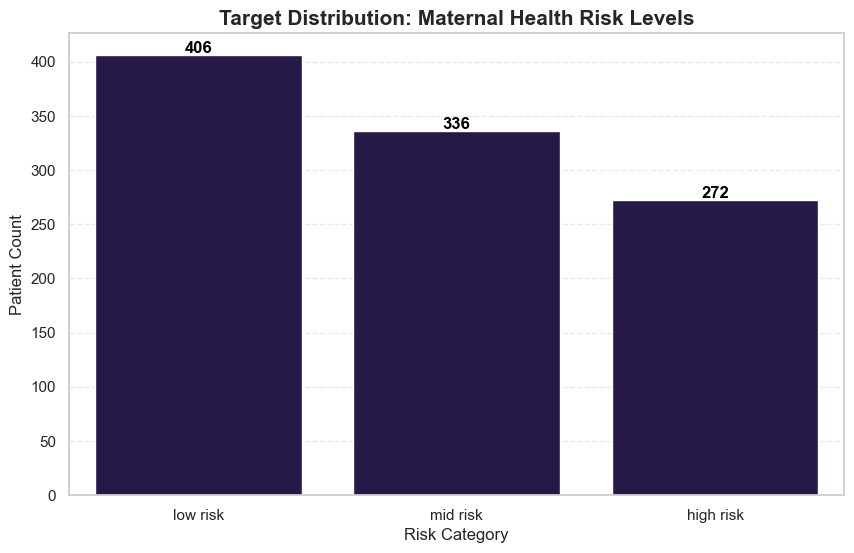

In [3]:
plt.figure(figsize=(10, 6))
sns.set_palette("magma")
ax = sns.countplot(data=df, x='RiskLevel', order=['low risk', 'mid risk', 'high risk'])

# Adding annotations for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points', fontweight='bold')

plt.title('Target Distribution: Maternal Health Risk Levels', fontsize=15, fontweight='bold')
plt.xlabel('Risk Category', fontsize=12)
plt.ylabel('Patient Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('../figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Feature Distribution by Risk Level

Analyzing how key physiological metrics vary across different risk categories using Seaborn `boxplots`.

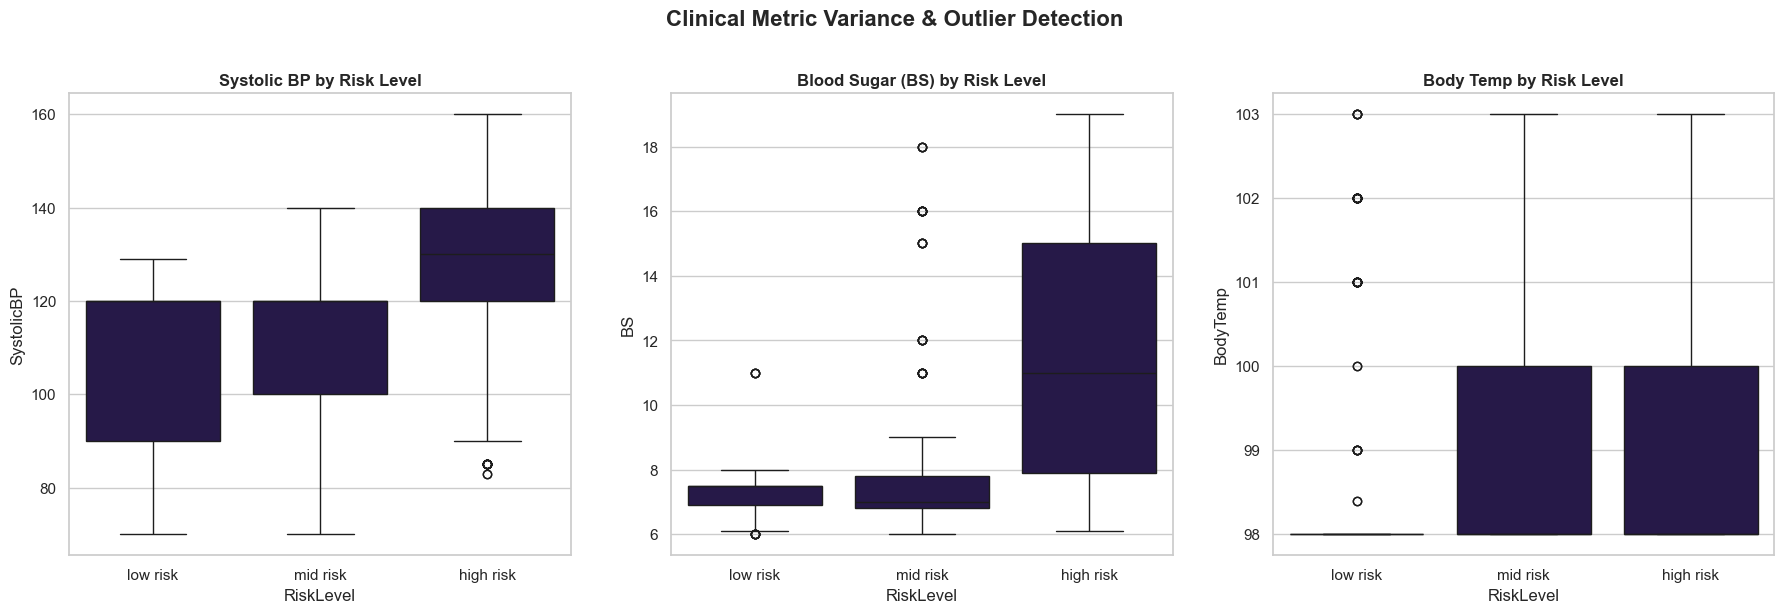

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
sns.set_palette("viridis")

sns.boxplot(ax=axes[0], data=df, x='RiskLevel', y='SystolicBP', order=['low risk', 'mid risk', 'high risk'])
axes[0].set_title('Systolic BP by Risk Level', fontweight='bold')

sns.boxplot(ax=axes[1], data=df, x='RiskLevel', y='BS', order=['low risk', 'mid risk', 'high risk'])
axes[1].set_title('Blood Sugar (BS) by Risk Level', fontweight='bold')

sns.boxplot(ax=axes[2], data=df, x='RiskLevel', y='BodyTemp', order=['low risk', 'mid risk', 'high risk'])
axes[2].set_title('Body Temp by Risk Level', fontweight='bold')

plt.suptitle('Clinical Metric Variance & Outlier Detection', fontsize=16, y=1.02, fontweight='bold')
plt.savefig('../figures/clinical_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Correlation Matrix: BEFORE Feature Engineering

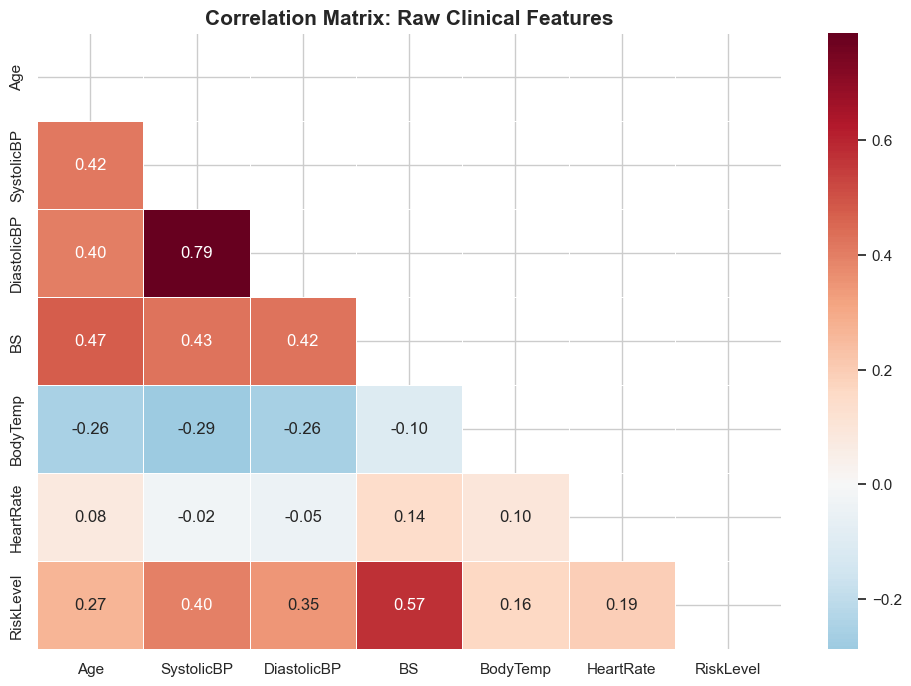

In [5]:
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(df_encoded.corr(), dtype=bool))
sns.heatmap(df_encoded.corr(), annot=True, cmap='RdBu_r', center=0, mask=mask, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Raw Clinical Features', fontsize=15, fontweight='bold')
plt.savefig('../figures/correlation_before_fe.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Applying Feature Engineering

We apply clinical metrics such as Mean Arterial Pressure (MAP), Pulse Pressure, and Shock Index.

In [6]:
# Clinical Feature Engineering
df_encoded["MAP"] = (df_encoded["SystolicBP"] + 2 * df_encoded["DiastolicBP"]) / 3
df_encoded["PulsePressure"] = df_encoded["SystolicBP"] - df_encoded["DiastolicBP"]
df_encoded["ShockIndex"] = df_encoded["HeartRate"] / df_encoded["SystolicBP"]
df_encoded["BPRatio"] = df_encoded["SystolicBP"] / df_encoded["DiastolicBP"]

# Use temporary variables for deviations to keep the dataset clean from redundant features
temp_dev = df_encoded["BodyTemp"] - 98.2

df_encoded["CombinedRiskScore"] = (
    (df_encoded["MAP"] > 105).astype(int) +
    (df_encoded["BS"] > 10).astype(int) +
    (df_encoded["HeartRate"] > 90).astype(int) +
    (temp_dev > 1).astype(int)
)

print("Feature engineering complete. (Redundant columns BSDeviation/TempDeviation removed)")

Feature engineering complete. (Redundant columns BSDeviation/TempDeviation removed)


## 5. Correlation Matrix: AFTER Feature Engineering

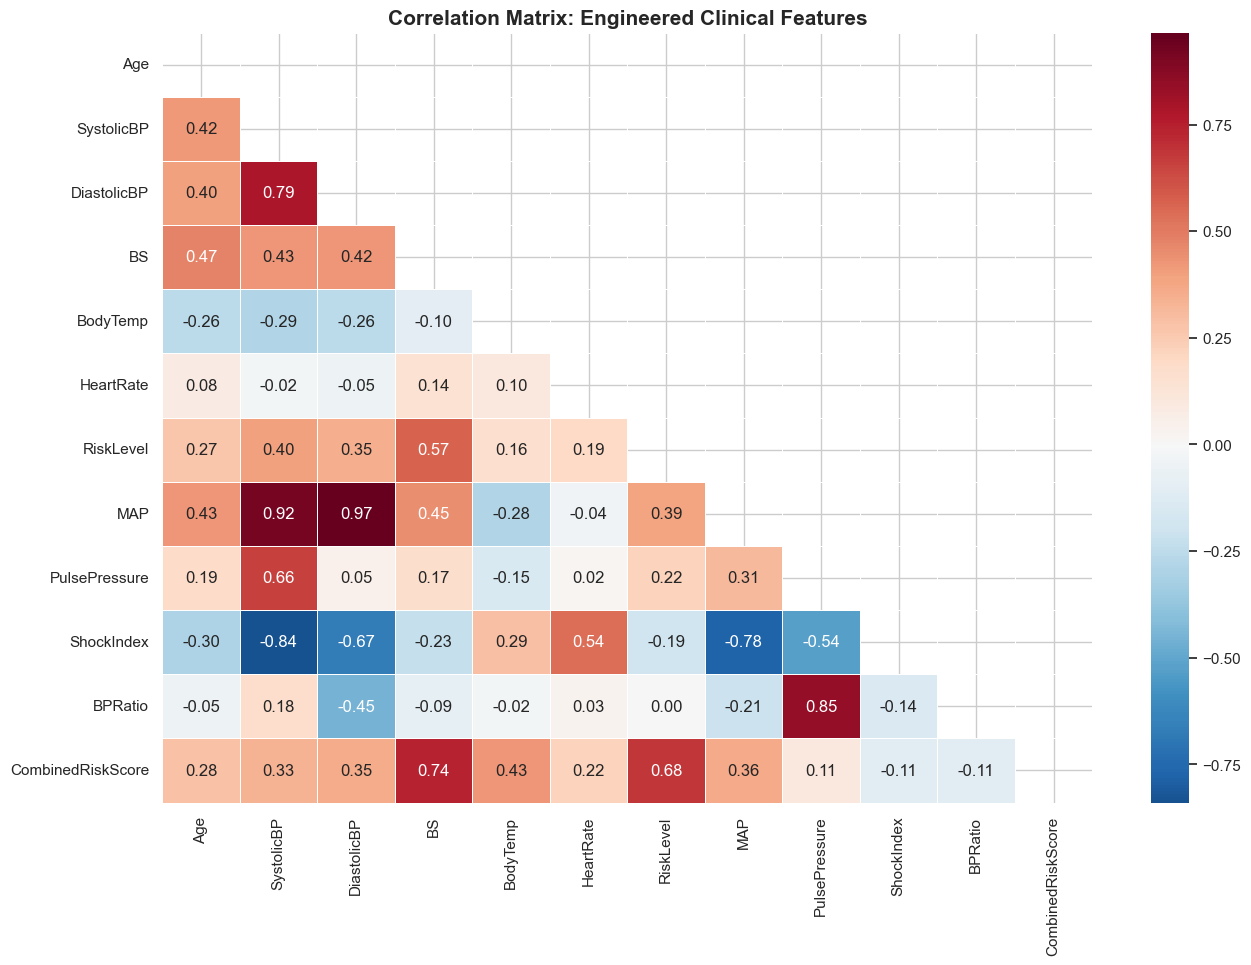

In [7]:
plt.figure(figsize=(15, 10))
mask = np.triu(np.ones_like(df_encoded.corr(), dtype=bool))
sns.heatmap(df_encoded.corr(), annot=True, cmap='RdBu_r', center=0, mask=mask, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Engineered Clinical Features', fontsize=15, fontweight='bold')
plt.savefig('../figures/correlation_after_fe.png', dpi=150, bbox_inches='tight')
plt.show()